# Raport: Symulator Tomografu Komputerowego

#### Skład grupy

Julia Kardasz 160204
Szymon Wójtowicz 

## Specyfikacja i Model
### Biblioteki

In [1]:
import os
import matplotlib.pyplot as plt
from PIL import Image

In [2]:
class StopNotebook(Exception):
    def __init__(self, msg="Brak dodatkowych informacji."):
        self.msg = msg
        
    def _render_traceback_(self):
        return [f"--- NOTATNIK ZATRZYMANY ---", f"Powód: {self.msg}"]

### Zastosowany model tomografu: stożkowy
### Model symulacji pochłaniania i normalizacja

---

## Opis Implementacji i Funkcji

### Wczytywanie plików 

In [3]:
path = "image.bmp"

if os.path.exists(path):
    img = Image.open(path).convert('L')
    root, extension = os.path.splitext(path)

    if extension.lower() != ".bmp":
        raise StopNotebook(msg="Zły format pliku")

    width, height = img.size
    print(f"Szerokość: {width} px")
    print(f"Wysokość: {height} px")
else:
    raise StopNotebook(msg="Nie można znaleźć pliku.")

square = False
rectangle = False
if width > height or height > width:
    rectangle = True
    print("Obraz jest prostokątny.")
elif width == height:
    square = True
    print("Obraz jest kwadratowy.")

if not square and not rectangle:
    raise StopNotebook(msg="Niewłaściwy kształt obrazu.")

Szerokość: 404 px
Wysokość: 501 px
Obraz jest prostokątny.


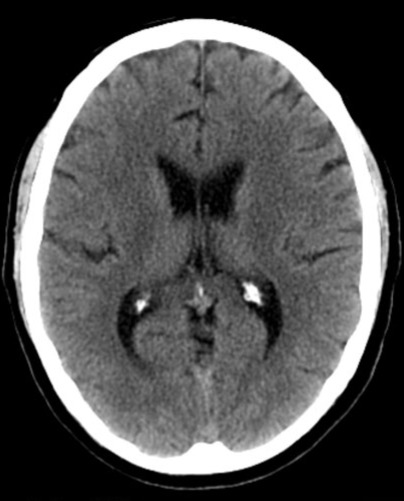

In [4]:
img

### Transformata Radona (Bresenham)

c:\Users\szymw\AppData\Local\Programs\Python\Python312\Lib\site-packages\skimage\transform\radon_transform.py:74: UserWarning: Radon transform: image must be zero outside the reconstruction circle
  warn(


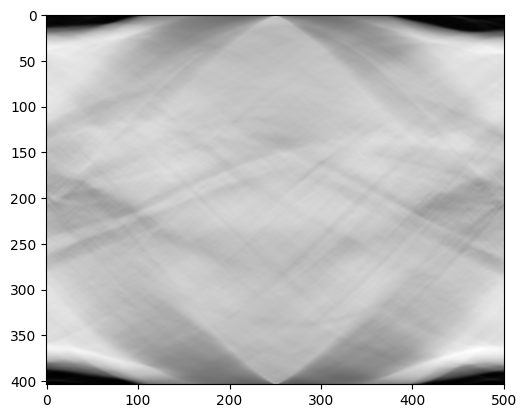

In [ ]:
#import sys
#!{sys.executable} -m pip install -U scikit-image
#odkomentuj jeśli nie działa
import numpy as np
from skimage.data import shepp_logan_phantom
from skimage.transform import radon, rescale

image = np.array(img)

sinogram = radon(image, theta=np.linspace(0,180,max(image.shape), endpoint=False))

plt.imshow(sinogram,cmap=plt.cm.Greys_r)

### Filtrowanie sinogramu i splot 


### Przetwarzanie końcowe i wyznaczanie jasności pikseli


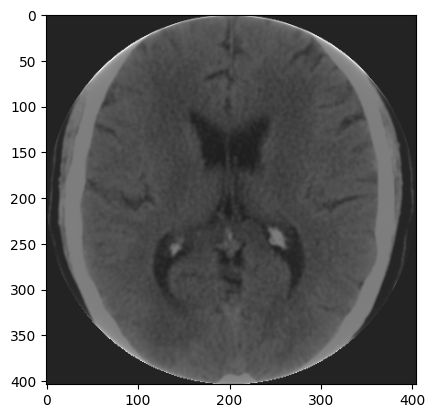

In [32]:
from skimage.transform import iradon
result = iradon(sinogram, theta=np.linspace(0,180,max(image.shape), endpoint=False))
plt.imshow(result,cmap=plt.cm.Greys_r)

### Wyznaczanie miary RMSE 


### Obsługa plików DICOM



---

## Przykłady Działania Programu

### Przypadek testowy 1
* **Obraz wejściowy:**
* **Sinogram:**
* **Obraz wyjściowy (rekonstrukcja):**

### Przypadek testowy 2 (z filtrowaniem)
* **Obraz wejściowy:**
* **Obraz wyjściowy bez filtra:**
* **Obraz wyjściowy z filtrem:**

---


## Analiza Statystyczna i Wyniki Eksperymentów

### 1. Wpływ liczby detektorów na RMSE (90 - 720)
* **Wykres:**
* **Komentarz:**

### 2. Wpływ liczby skanów na RMSE (90 - 720)
* **Wykres:**
* **Komentarz:**

### 3. Wpływ rozpiętości układu na RMSE (45° - 270°)
* **Wykres:**
* **Komentarz:**

### 4. Porównanie wpływu filtrowania (360 det., 360 skanów, 270°)
* **Tabela wyników RMSE:**
* **Komentarz i subiektywna ocena jakości:**

---
